# Malignant Cell Dynamics and TCR Repertoire Evolution Following PD-1 Blockade (Figure 5)

**Manuscript Context:** This notebook contains the code and workflows used to generate **Figure 5a–g** and **Table 8-9** for our study on Extranodal NK/T-cell lymphoma (ENKTCL).

**Objective:**
The goal of this analysis is to characterize the longitudinal dynamics of malignant cells and the evolution of the T-cell receptor (TCR) repertoire in response to PD-1 blockade therapy. Specifically, we:
1.  Investigate the inter-patient variability in the dynamic changes of malignant NK and T-cell subsets (e.g., NK08:Malig_IL2RA, T13:Malig_MSI2) following immunochemotherapy, assessing shifts in both global proportions and intra-patient composition.
2.  Perform functional enrichment analysis to identify significantly altered signaling pathways (KEGG, GO, and Hallmark) across distinct malignant T and NK cell states.
3.  Utilize crater plots to visualize the intersection of gene expression changes, distinguishing between genes driven by malignancy (Malignant vs. Normal) and those modulated by therapy (Pre-ICI vs. Post-ICI).
4.  Analyze the accumulated expansion curves of TCR clonotypes to measure the magnitude of clonal activity and diversity before and after treatment.
5.  Evaluate "responder" and "non-responder" gene signatures within persistent T-cell clonal types, comparing dynamics in non-recurrence patients against a patient with disease recurrence to identify potential markers of therapeutic failure.

In [844]:
import anndata as ad
import matplotlib.pyplot as plt
import muon as mu
import pandas as pd
import scanpy as sc
import scirpy as ir
import numpy as np
import os
import seaborn as sns
from scipy.sparse import csc_matrix, csr_matrix
from collections import Counter
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter, PercentFormatter
import sys
print(sys.version)

3.11.11 (main, Dec 11 2024, 16:28:39) [GCC 11.2.0]


In [845]:
figPath = "./figures/fig5"
tablePath = "./tables"
irPath = "./data/NKTCL-ir.h5ad"
TPath = './data/NKTCL_T.h5ad'
CD8TPath = './data/NKTCL_CD8T.h5ad'
CD4TPath = './data/NKTCL_CD4T.h5ad'
NKPath = './data/NKTCL_NK.h5ad'
TprolPath = './data/NKTCL_Tprol.h5ad'
# Check if the directory exists, if not, create it (including parent directories if necessary)
os.makedirs(figPath, exist_ok=True)

In [ ]:
adata_T = sc.read_h5ad(TPath)
adata_NK = sc.read_h5ad(NKPath)
adata_Tprol = sc.read_h5ad(TprolPath)
adata_CD8T = sc.read_h5ad(CD8TPath)
adata_CD4T = sc.read_h5ad(CD4TPath)
nktcl_ir = sc.read_h5ad(irPath)

#### **Fig. 5a** Individual variability in dynamic changes in malignant NK and T-cell subsets following immunochemotherapy across five patients. 
The upper panel depicts the changes in the proportions of malignant cells in the NK and T clusters.

The lower panel depicts malignant cell composition changes within each patient.

In [857]:
# Calculate the proportions and absolute counts of malignant NK and T cell subsets for each patient across Pre- and Post-ICI timepoints
df1 = []
df2 = []
df3 = []
pids = ['NK5', 'NK6', 'NK7', 'NK8', 'NK11']
for pid in pids:
  pre_NK = adata_NK[adata_NK.obs['batch'] == f'{pid}_0']
  post_NK = adata_NK[adata_NK.obs['batch'] == f'{pid}_1']
  pre_T = adata_T[adata_T.obs['batch'] == f'{pid}_0']
  post_T = adata_T[adata_T.obs['batch'] == f'{pid}_1']
  pre_mNK1, post_mNK1 = len(pre_NK[pre_NK.obs['CellStateLabels'].isin(['NK08: Malig_IL2RA', 'NK09: Malig_H2AC11'])]), \
    len(post_NK[post_NK.obs['CellStateLabels'].isin(['NK08: Malig_IL2RA', 'NK09: Malig_H2AC11'])])
  pre_mNK2, post_mNK2 = len(pre_NK[pre_NK.obs['CellStateLabels'].isin(['NK01: Malig_MKI67', 'NK02: Malig_CD56', 'NK03: Malig_CD16',
       'NK04: Malig_CD200R1', 'NK05: Malig_FGFBP2'])]), \
    len(post_NK[post_NK.obs['CellStateLabels'].isin(['NK01: Malig_MKI67', 'NK02: Malig_CD56', 'NK03: Malig_CD16',
       'NK04: Malig_CD200R1', 'NK05: Malig_FGFBP2'])])
  pre_mT1, post_mT1 = len(pre_T[pre_T.obs['anno-subTfixed'] == 'C12_Tprol_MKI67']), len(post_T[post_T.obs['anno-subTfixed'] == 'C12_Tprol_MKI67'])
  pre_mT2, post_mT2 = len(pre_T[pre_T.obs['anno-subTfixed'] == 'C13_Malig_MSI2']), len(post_T[post_T.obs['anno-subTfixed'] == 'C13_Malig_MSI2'])
  df1.append([(pre_mNK1+pre_mNK2+pre_mT1+pre_mT2) / (len(pre_T) + len(pre_NK)),(post_mNK1+post_mNK2+post_mT1+post_mT2) / (len(post_T) + len(post_NK))])
  df2.append([pre_mNK1, pre_mNK2, pre_mT1, pre_mT2])
  df3.append([post_mNK1, post_mNK2, post_mT1, post_mT2])
df1 = pd.DataFrame(df1, columns=['Pre', 'Post'], index=pids)
df1['Sample'] = df1.index
df2 = pd.DataFrame(df2, columns=['MaligNK_chr6p21Del', 'MaligNK_chr6p21Amp', 'MaligT MKI67', 'MaligT MSI2'], index=pids)
df3 = pd.DataFrame(df3, columns=['MaligNK_chr6p21Del', 'MaligNK_chr6p21Amp', 'MaligT MKI67', 'MaligT MSI2'], index=pids)

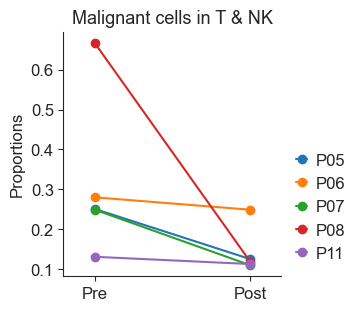

In [861]:
plt.rcParams["font.size"] = 12
labels = ['P05', 'P06', 'P07', 'P08', 'P11']
fig, ax = plt.subplots(1,1,figsize=(3.5,3), constrained_layout=True)
data = pd.melt(df1,id_vars='Sample', var_name='Group', value_name='Value')
for i, sample in enumerate(df1['Sample']):
  sample_data = data[data['Sample'] == sample]
  ax.plot(sample_data['Group'], sample_data['Value'], marker='o', label=labels[i], linestyle='-')
ax.set_xlim(-0.2,1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Proportions')
ax.legend( bbox_to_anchor=(1, 0), 
          handletextpad=0.5, frameon=False,
                      borderpad=0.4,
                      columnspacing=1,
                      handlelength=0.65,
          loc='lower left')
ax.set_title("Malignant cells in T & NK", fontsize=13)
fig.savefig(f"{figPath}/Fig5a-upper.pdf", bbox_inches='tight')

In [ ]:
# ---------------------------------------------------------
# Generate stacked bar plots for cell proportion analysis
# ---------------------------------------------------------
# This function visualizes the relative abundance of different 
# cell types or states across samples (e.g., patients). It 
# normalizes the input count data to percentages and generates 
# a horizontal stacked bar chart, allowing for easy comparison 
# of compositional differences between groups.
# ---------------------------------------------------------
def propPlot(age_df, barlabels, ax, colors=sc.pl.palettes.default_20, xlabel='Patient ID', show_y=True, xrotate=90):
    all_df = age_df.sum(axis=1)
    age_normdf = pd.DataFrame([age_df.loc[i,:]/all_df[i] for i in barlabels], index=barlabels)
    age_cumdf = pd.DataFrame([np.cumsum(age_normdf.loc[i,:]) for i in barlabels], index=barlabels)
    norm_gdfs = age_normdf
    cum_gdfs = age_cumdf
    for i, col in enumerate(age_df.columns):
        height = norm_gdfs[col]
        starts = cum_gdfs[col] - height
        rects = ax.barh(barlabels, height, left=starts, height=0.9, color=colors[i], edgecolor='white', linewidth=0.5,
                        label=col, alpha=1)
    
        # ax.bar_label(rects,age_df.loc[:, col], label_type='center', color='lightgrey', fontsize=14)
    ax.legend( bbox_to_anchor=(1, 0), 
              handletextpad=0.5, frameon=False,
                          borderpad=0.4,
                          columnspacing=1,
                          handlelength=0.65,
              loc='lower left')
    if show_y:
        ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1,decimals=0))
        ax.set_xlabel('Cell proportions')
    else:
        ax.yaxis.set_visible(False)
    ax.set_ylabel(xlabel)
    # ax.set_yticks(barlabels)
    # ax.set_xticklabels(labels=barlabels,rotation=xrotate)
    ax.spines.top.set_visible(False)
    ax.spines.right.set_visible(False)

/tmp/ipykernel_3335451/1746669734.py:4: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_3335451/1746669734.py:5: UserWarning:

constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.

/home/rzh/miniconda3/lib/python3.11/site-packages/IPython/core/events.py:89: UserWarning:

constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.

/home/rzh/miniconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning:

constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.



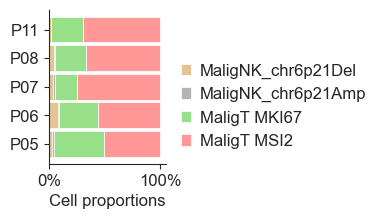

In [862]:
barlabels = list(df2.index)
fig, ax = plt.subplots(1,1,figsize=(1.5,2), constrained_layout=True)
propPlot(df3, barlabels, ax, colors=['#e5c494', '#b3b3b3', '#98df8a', '#ff9896'], xlabel='', show_y=True)
ax.set_yticklabels(labels)
fig.savefig(f"{figPath}/Fig5a-lower.pdf", bbox_inches='tight')

#### **Fig. 5b** The bar plots show the significance of gene set enrichment (−log10(q-value)) for selected signaling pathways in distinct malignant T and NK cell states. 
Each column represents a specific malignant T or NK subset (e.g., NK08:Malig_IL2RA, T13:Malig_MSI2, etc.), and each row corresponds to a curated gene set from KEGG, GO, or Hallmark (HM) databases. Pathways with q < 0.05 were considered significant.

In [ ]:
import gseapy as gp
from gseapy import Msigdb

def prep_enrichr(adata, groupby):
  """
  Prepares differential expression results for enrichment analysis.
  
  This function performs differential expression analysis using Scanpy's 
  rank_genes_groups method and organizes the results into a structured 
  DataFrame. It extracts gene names, scores, p-values, and log fold changes 
  for all groups, formatting them for downstream enrichment analysis.
  
  Parameters:
  -----------
  adata : AnnData
      The annotated AnnData object containing the single-cell data.
  groupby : str
      The key in adata.obs that defines the groups for comparison.
      
  Returns:
  --------
  pandas.DataFrame
      A DataFrame containing differential expression results with columns 
      formatted as 'group_key' (e.g., 'cluster_names', 'cluster_pvals').
  """
  # de analysis
  sc.tl.rank_genes_groups(adata, groupby=groupby)
  sc.tl.dendrogram(adata, groupby=groupby)
  # get deg result
  result = adata.uns['rank_genes_groups']
  groups = result['names'].dtype.names
  degs = pd.DataFrame(
      {group + '_' + key: result[key][group]
      for group in groups for key in ['names','scores', 'pvals','pvals_adj','logfoldchanges']})
  return degs

def run_enrichr_genelist(genelist):
  """
  Performs enrichment analysis on a list of genes using multiple databases.
  
  This function runs enrichment analysis on the provided gene list using 
  five different gene set libraries: KEGG pathways, GO Cellular Component, 
  MSigDB Hallmark, GO Molecular Function, and GO Biological Process. It 
  returns the results from all five analyses for comprehensive functional 
  annotation.
  
  Parameters:
  -----------
  genelist : list
      A list of gene symbols to be analyzed for enrichment.
      
  Returns:
  --------
  tuple
      A tuple containing five enrichment result objects (KEGG, Cellular 
      Component, Hallmark, Molecular Function, Biological Process).
  """
  kegg = gp.enrichr(genelist,
                  gene_sets='KEGG_2021_Human',
                  outdir=None)
  cc = gp.enrichr(genelist,
                      gene_sets='GO_Cellular_Component_2023',
                      outdir=None)
  hm = gp.enrichr(genelist,
                      gene_sets=['MSigDB_Hallmark_2020'],
                      outdir=None)
  mf = gp.enrichr(genelist,
                      gene_sets='GO_Molecular_Function_2023',
                      outdir=None)
  bp = gp.enrichr(genelist,
                      gene_sets=['GO_Biological_Process_2023'],
                      outdir=None)
  return kegg, cc, hm, mf, bp

def run_enrichr_scanpy(degs, group,direction='up', top_term=15, all_term=False, plot=True):
  """
  Performs enrichment analysis on Scanpy differential expression results.
  
  This function filters differentially expressed genes based on adjusted 
  p-value and log fold change, then performs enrichment analysis on either 
  up-regulated or down-regulated genes. It combines results from multiple 
  databases and optionally generates a bar plot of the top enriched terms.
  
  Parameters:
  -----------
  degs : pandas.DataFrame
      DataFrame containing differential expression results from prep_enrichr.
  group : str
      The group name to analyze (e.g., 'cluster_0').
  direction : str, optional
      Either 'up' or 'down' to specify direction of regulation.
  top_term : int, optional
      Number of top enriched terms to display in the plot.
  all_term : bool, optional
      If True, returns all enriched terms instead of just the top ones.
  plot : bool, optional
      If True, generates a bar plot of enriched terms.
      
  Returns:
  --------
  tuple
      A tuple containing the enrichment results DataFrame and the plot axis 
      (or None if plot=False).
  """
  # subset up or down regulated genes
  degs_sig = degs[degs[f'{group}_pvals_adj'] < 0.05]
  degs_up = degs_sig[degs_sig[f'{group}_logfoldchanges'] > 0]
  degs_dw = degs_sig[degs_sig[f'{group}_logfoldchanges'] < 0]
  degs_used = degs_up[f'{group}_names'] if direction == 'up' else degs_dw[f'{group}_names']
  kegg, cc, hm, mf, bp = run_enrichr_genelist(degs_used)
  go_res = pd.concat([kegg.res2d.head(top_term),
                    hm.res2d.head(top_term), 
                    cc.res2d.head(top_term), 
                    bp.res2d.head(top_term), 
                    mf.res2d.head(top_term)])
  if plot:
    ax = gp.barplot(go_res, figsize=(6,20),
                group ='Gene_set',
                top_term=top_term,
                color = ['#8b9cc4', '#f08961', '#62bb9f', '#e71f19', '#3d5eaa'],
                title ="The Most Enriched Terms")
  else:
    ax = None
  if all_term:
    go_res = pd.concat([kegg.res2d, hm.res2d, cc.res2d, bp.res2d, mf.res2d])
  return go_res, ax

In [ ]:
# Perform functional enrichment analysis (Enrichr) on specific malignant T and NK cell 
# subsets to identify significantly enriched pathways and biological processes
NK_degs = prep_enrichr(adata_NK, groupby='CellStateLabels')
T_degs = prep_enrichr(adata_T, groupby='CellStateLabels')
Malig_T1, ax = run_enrichr_scanpy(T_degs,'T13: Malig_MSI2',direction='up', top_term=15, all_term=True, plot=False)
Malig_T2, ax = run_enrichr_scanpy(T_degs,'T12: Tprol_MKI67',direction='up', top_term=15, all_term=True, plot=False)
Malig_NK1, ax = run_enrichr_scanpy(NK_degs,'NK08: Malig_IL2RA',direction='up', top_term=15, all_term=True, plot=False)
Malig_NK2, ax = run_enrichr_scanpy(NK_degs, 'NK09: Malig_H2AC11',direction='up', top_term=15, all_term=True, plot=False)
Malig_NK3, ax = run_enrichr_scanpy(NK_degs,'NK01: Malig_MKI67',direction='up', top_term=15, all_term=True, plot=False)
Malig_NK4, ax = run_enrichr_scanpy(NK_degs,'NK02: Malig_CD56',direction='up', top_term=15, all_term=True, plot=False)

In [865]:
Selected_Pathway = [
  'Mitotic Spindle',
  'Protein Serine/Threonine Kinase Activity (GO:0004674)',
  'Phosphorylation (GO:0016310)',
  'Peptidyl-Serine Phosphorylation (GO:0018105)',
  'Phosphatidylinositol signaling system',
  'Inositol phosphate metabolism',
  'GTPase Regulator Activity (GO:0030695)',
  'Guanyl-Nucleotide Exchange Factor Activity (GO:0005085)',
  'T cell receptor signaling pathway',
  'Ubiquitin mediated proteolysis',
  'Epithelial Mesenchymal Transition',
  'Systemic lupus erythematosus',
  'Neutrophil extracellular trap formation',
  'Collagen-Containing Extracellular Matrix (GO:0062023)',
  'E2F Targets',
  'RNA Binding (GO:0003723)',
  'Myc Targets V1',
  'Oxidative Phosphorylation',
  'G2-M Checkpoint',
  'mTORC1 Signaling',
  'Myc Targets V2',
  'Mitochondrial Matrix (GO:0005759)',
  'Interferon Alpha Response',
  'Interferon Gamma Response',
  'TNF-alpha Signaling via NF-kB',
  'Epstein-Barr virus infection',
  'Allograft Rejection',
  'Antigen processing and presentation'
]

/tmp/ipykernel_3335451/3952054505.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_3335451/3952054505.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_3335451/3952054505.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ip

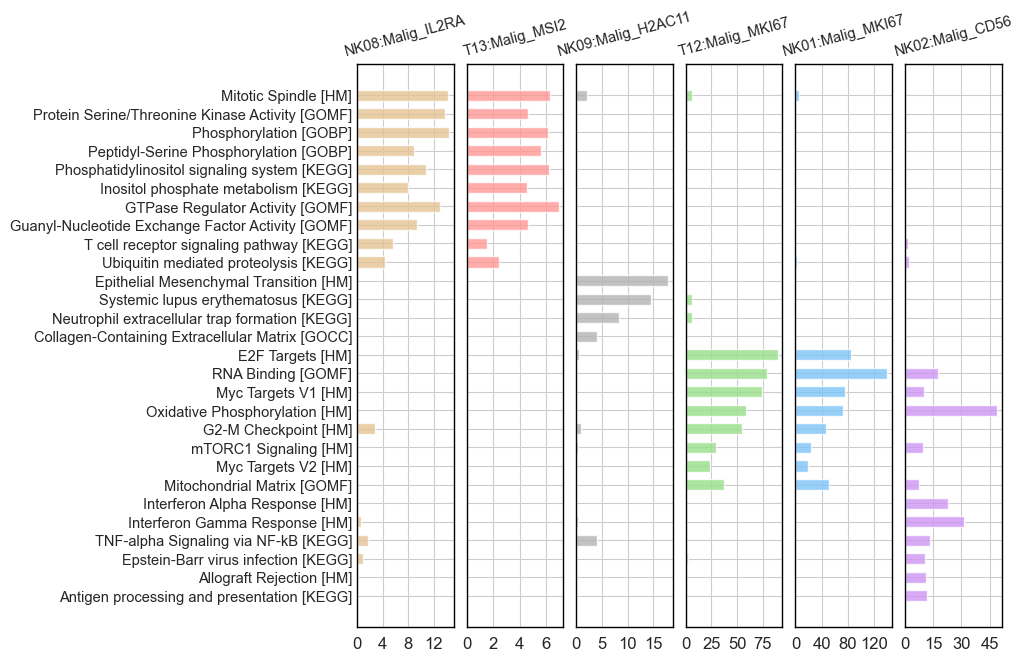

In [866]:
# Generate horizontal bar plots visualizing the significance (-log10 P-value) 
# of selected signaling pathways across distinct malignant T and NK cell states
from matplotlib.ticker import MaxNLocator
import seaborn as sns
sns.set_style('whitegrid')
fig, ax = plt.subplots(1, 6, figsize=(10, 6.5), constrained_layout=True)
datas = [ Malig_NK1,Malig_T1, Malig_NK2,  Malig_T2,Malig_NK3, Malig_NK4,]
labels = ['NK08:Malig_IL2RA', 'T13:Malig_MSI2', 'NK09:Malig_H2AC11', 'T12:Malig_MKI67', 'NK01:Malig_MKI67', 'NK02:Malig_CD56']
colors = ['#e5c494', '#ff9896', '#b3b3b3','#98df8a', "#7dc4f7", "#cf95f3"]
for i, d in enumerate(datas):
  data = d.loc[d['Term'].isin(Selected_Pathway),:]
  data['Term'] = pd.Categorical(data['Term'], categories=Selected_Pathway, ordered=True)
  data = data.sort_values(by='Term', ascending=False)
  rects = ax[i].barh(data['Term'], 
                  -np.log10(data['Adjusted P-value']), 
                  height=0.6, alpha=0.8,
                  label=labels[i], color=colors[i])
  ax[i].set_title(labels[i], fontsize=10.5,rotation=15)
  ax[i].xaxis.set_major_locator(MaxNLocator(nbins=4))
  ax[i].tick_params(axis='y', which='both', length=0)
  ax[i].tick_params(axis='x', which='both', length=3)
  for spine in ax[i].spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.0)
  if i > 0:
    ax[i].set_yticklabels([])
ax[0].set_yticklabels([
  'Antigen processing and presentation [KEGG]',
  'Allograft Rejection [HM]',
  'Epstein-Barr virus infection [KEGG]',
  'TNF-alpha Signaling via NF-kB [KEGG]',
  'Interferon Gamma Response [HM]',
  'Interferon Alpha Response [HM]',
  'Mitochondrial Matrix [GOMF]',
  'Myc Targets V2 [HM]',
  'mTORC1 Signaling [HM]',
  'G2-M Checkpoint [HM]',
  'Oxidative Phosphorylation [HM]',
  'Myc Targets V1 [HM]',
  'RNA Binding [GOMF]',
  'E2F Targets [HM]',
  'Collagen-Containing Extracellular Matrix [GOCC]',
  'Neutrophil extracellular trap formation [KEGG]',
  'Systemic lupus erythematosus [KEGG]',
  'Epithelial Mesenchymal Transition [HM]',
  'Ubiquitin mediated proteolysis [KEGG]',
  'T cell receptor signaling pathway [KEGG]',
  'Guanyl-Nucleotide Exchange Factor Activity [GOMF]',
  'GTPase Regulator Activity [GOMF]',
  'Inositol phosphate metabolism [KEGG]',
  'Phosphatidylinositol signaling system [KEGG]',
  'Peptidyl-Serine Phosphorylation [GOBP]',
  'Phosphorylation [GOBP]',
  'Protein Serine/Threonine Kinase Activity [GOMF]',
  'Mitotic Spindle [HM]',
], fontsize=10.5)
fig.savefig(f"{figPath}/Fig5b.pdf", bbox_inches='tight')

#### **Fig. 5c** The crater plot displays genes differentially expressed between malignant T cells and normal T cells (x-axis) or between pre-ICI and post-ICI samples (y-axis).

In [ ]:
# ---------------------------------------------------------
# Differential Expression Analysis using Memento (1D)
# ---------------------------------------------------------
# This function performs differential expression analysis 
# between two groups of cells using the Memento framework. 
# It subsets the input AnnData object based on the specified 
# cell types, prepares the data by setting up Memento with 
# a capture rate, and defines the treatment groups. It then 
# computes the 1D moments, sets up the statistical model 
# with a covariate and treatment variable, and runs the 
# hypothesis testing. The function returns the resulting 
# differential expression statistics.
# ---------------------------------------------------------
import memento
def DE_memento_1d(adata: ad.AnnData, ctleft: list, ctright: list, groupby='annotation'):
  _adata = adata[adata.obs[groupby].isin(ctleft + ctright)].copy()
  _adata = ad.AnnData(_adata.layers['Raw'], obs = _adata.obs, var = _adata.var)
  _adata.obs['stim'] = _adata.obs[groupby].isin(ctright)
  _adata.obs['stim'] = _adata.obs['stim'].astype('int')
  _adata.obs['capture_rate'] = 0.07
  memento.setup_memento(_adata, q_column='capture_rate')
  memento.create_groups(_adata, label_columns=['stim'])
  memento.compute_1d_moments(_adata, min_perc_group=.7)
  meta_df = memento.get_groups(_adata)
  meta_df['intercept'] = 1
  convariate = meta_df[['intercept']]
  treatment = (meta_df[['stim']] == 1).astype(float)
  
  memento.ht_1d_moments(_adata,
  covariate=convariate,
  treatment=treatment,
  num_cpus=16,
  resample_rep=False,
  )
  memento_results = memento.get_1d_ht_result(_adata)
  return(memento_results)

In [867]:
# ---------------------------------------------------------
# 2D Differential Expression Scatter Plot with Label Adjustment
# ---------------------------------------------------------
# This function generates a 2D scatter plot to visualize 
# differential expression results from two different comparisons 
# (e.g., cell type specificity vs. treatment response). It 
# identifies significant genes based on coefficient and p-value 
# thresholds, mapping significance to color and point size. 
# Crucially, it uses the `adjustText` library to automatically 
# adjust gene labels and prevent overlap, ensuring readability. 
# The plot includes reference lines for significance cutoffs 
# and a custom legend for point sizes.
# ---------------------------------------------------------
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import adjustText as adjust

def DEplot_2D(deg_anno:pd.DataFrame, deg_treat:pd.DataFrame, coef=0.5, c='coolwarm'):
    # Define a helper function to map p-values to point sizes for the legend
    def calculate_size(p):
        min_p = 1e-20
        max_p = 1e-5
        min_size = 30
        max_size = 120
        return ((p - min_p) / (max_p - min_p)) * (max_size - min_size) + min_size

    # Identify genes present in both input dataframes to ensure consistent plotting
    genes = list(set(deg_anno['gene']).intersection(deg_treat['gene']))
    # Create copies of the input dataframes to avoid modifying the originals
    anno_df = deg_anno.copy()
    treat_df = deg_treat.copy()
    # Filter dataframes to include only the common genes
    anno_df = anno_df[anno_df['gene'].isin(genes)]
    # Set gene as the index for easier alignment
    anno_df.index = anno_df['gene']
    # Add suffix to column names to distinguish from the other dataframe
    anno_df.columns = [s + '_anno' for s in anno_df.columns]
    # Filter and process the second dataframe similarly
    treat_df = treat_df[treat_df['gene'].isin(genes)]
    treat_df.index = treat_df['gene']
    treat_df.columns = [s + '_treat' for s in treat_df.columns]
    # Concatenate the two dataframes along the columns (axis=1)
    df = pd.concat([anno_df, treat_df], axis=1)

    # Initialize lists to store visual properties for each point
    colors = []
    sizes = []
    alphas = []
    color_values = []

    # Iterate through each gene to determine its visual representation
    for i in range(len(df)):
        # Check if the gene is NOT significant in either comparison
        if -coef < df['de_coef_anno'][i] < coef or \
            -coef < df['de_coef_treat'][i] < coef or \
            df['de_pval_anno'][i] > 1e-5 or \
            df['de_pval_treat'][i] > 1e-5:
            # Assign gray color, small size, and low alpha for non-significant genes
            sizes.append(20)
            alphas.append(0.3)
            colors.append('gray')
        else:
            # For significant genes, use the coefficient from the 'anno' comparison for color
            combined_value = df['de_coef_anno'][i]
            color_values.append(combined_value)
            colors.append(None)  # Placeholder to be filled later with colormap color
            # Size is based on the p-value from the 'treat' comparison
            sizes.append(calculate_size(df['de_pval_treat'][i]))
            alphas.append(1)

    # Create a color normalization object based on the range of coefficient values
    norm = Normalize(vmin=min(color_values), vmax=max(color_values))
    # Get the specified colormap
    cmap = plt.get_cmap(c)

    # Replace None placeholders in the colors list with actual colors from the colormap
    color_index = 0
    for i, color in enumerate(colors):
        if color is None:
            colors[i] = cmap(norm(color_values[color_index]))
            color_index += 1
    # Store the final colors in the dataframe
    df['sig'] = colors

    # Create the scatter plot using seaborn
    ax = sns.scatterplot(df,
                     x='de_coef_anno',
                     y='de_coef_treat',
                     color=colors,
                     s=sizes,
                     alpha=alphas,
                     zorder=0)

    # --- Label Addition and Adjustment ---
    # Initialize a list to hold text objects for adjustment
    texts = []
    # Iterate through points to add labels only for significant genes (colored points)
    for i, color in enumerate(colors):
        if isinstance(color, tuple):  # Check if the color is an RGBA tuple (significant)
            # Add a text label at the point's coordinates
            text = ax.text(
                df['de_coef_anno'][i],
                df['de_coef_treat'][i],
                df['gene_anno'][i],
                ha='center',
                va='center',
                fontsize=9,
                zorder=10
            )
            texts.append(text)

    # Use adjust_text to automatically reposition labels and minimize overlap
    # Arrows are added to connect labels to their original points
    adjust.adjust_text(texts,
                       arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
                       ax=ax)
    # --- End of Label Adjustment ---

    # Add dashed reference lines at the significance coefficient thresholds
    ax.axvline(x=coef, linestyle='--', color='black', zorder=3, linewidth=0.5)
    ax.axvline(x=-coef, linestyle='--', color='black', zorder=3, linewidth=0.5)
    ax.axhline(y=coef, linestyle='--', color='black', zorder=3, linewidth=0.5)
    ax.axhline(y=-coef, linestyle='--', color='black', zorder=3, linewidth=0.5)

    # Reposition the spines to pass through the origin (0,0)
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    # Hide the top and right spines
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    # Set the axis limits
    ax.set_xlim(-2.5, 1.7)
    ax.set_ylim(-1.8, 1.8)
    # Set custom tick locations
    ax.set_xticks([-1.5, -1, -0.5, 0.5, 1, 1.5])
    ax.set_yticks([-1.5, -1, -0.5, 0.5, 1, 1.5])
    # Ensure ticks are visible by setting their z-order
    for tick in ax.get_xticklines() + ax.get_yticklines():
        tick.set_zorder(10)
    # Ensure tick labels are visible
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_zorder(10)
    # Remove axis labels
    ax.set_xlabel('')
    ax.set_ylabel('')

    # Create custom legend elements for point sizes
    size_legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='50', markerfacecolor='black', markersize=np.sqrt(50)),
        Line2D([0], [0], marker='o', color='w', label='10', markerfacecolor='black', markersize=np.sqrt(30)),
        Line2D([0], [0], marker='o', color='w', label='No sig', markerfacecolor='black', markersize=np.sqrt(20))
    ]
    # Add the size legend to the plot
    first_legend = ax.legend(handles=size_legend_elements, loc='upper left', title='nelogP-value')
    ax.add_artist(first_legend)
    # Set the figure size
    ax.figure.set_size_inches(5, 4.5)
    return df, ax

In [868]:
ctleft = ['C01_Tn_CCR7', 'C02_Tcm_SELL', 'C03_Teff_IFNG', 'C04_XCL1_CD200-',
       'C05_XCL1_CD200+', 'C06_Tex_CD8', 'C07_Tex_CD4', 'C08_Treg_FOXP3',
       'C09_Th_CXCL13', 'C10_Tn/Tcm_IL7R', 'C11_Tctl_IFNG', 'C14_NK/NKT_NCAM1', ]
ctright = ['C12_Tprol_MKI67', 'C13_Malig_MSI2', ]
MvN_degs = DE_memento_1d(adata_T, 
                         ctleft = ctleft, 
                         ctright = ctright, 
                         groupby='anno-subTfixed')
ctleft = ['Pre']
ctright = ['Post']
MvN_treat_degs = DE_memento_1d(adata_T[adata_T.obs['anno-subTfixed'].isin(['C12_Tprol_MKI67', 'C13_Malig_MSI2',])], 
                         ctleft = ctleft, 
                         ctright = ctright, 
                         groupby='treatment')

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.9s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    5.1s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    8.4s
[Parallel(n_jobs=16)]: Done 768 tasks      | elapsed:   13.3s
[Parallel(n_jobs=16)]: Done 1218 tasks      | elapsed:   19.7s
[Parallel(n_jobs=16)]: Done 1768 tasks      | elapsed:   26.8s
[Parallel(n_jobs=16)]: Done 2418 tasks      | elapsed:   36.2s
[Parallel(n_jobs=16)]: Done 3168 tasks      | elapsed:   46.2s
[Parallel(n_jobs=16)]: Done 4018 tasks      | elapsed:   57.6s
[Parallel(n_jobs=16)]: Done 4968 tasks      | elapsed:  1.2min
[Parallel(n_jobs=16)]: Done 6018 tasks      | elapsed:  1.4min
[Parallel(n_jobs=16)]: Done 7010 out of 7010 | elapsed:  1.6min finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]:

/tmp/ipykernel_3335451/2177587855.py:58: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_3335451/2177587855.py:59: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_3335451/2177587855.py:60: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_3335451/2177587855.py:61: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated 

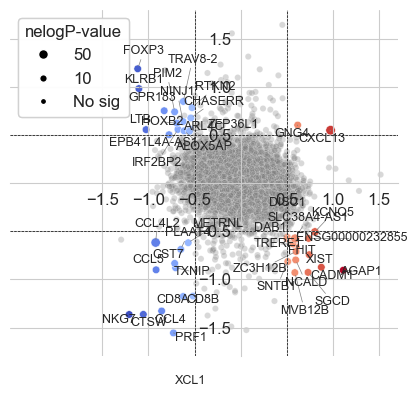

In [869]:
MvN_df, MvN_ax = DEplot_2D(MvN_degs, MvN_treat_degs)
MvN_ax.figure.savefig(f"{figPath}/Fig5c.pdf", bbox_inches='tight')

#### **Fig. 5d** Accumulated TCR expansion curves of pre-ICI and post-ICI samples. 
TCR clonotypes were sorted by expansion magnitude (from largest to smallest). The x-axis shows the cumulative proportion of top-ranked clonotypes included, and the y-axis shows the cumulative proportion of total TCR expansions they account for. A larger AUC indicates greater clonal expansion activity (i.e., more TCRs are concentrated in highly expanded clonotypes). Each curve represents a patient, with AUC values annotated. 

The Shannon index results regarding the clonality of the TCR repertoire also included in this section(Supplementary Table 9).

In [ ]:
# ---------------------------------------------------------
# Quantify and summarize TCR clonal expansion statistics
# ---------------------------------------------------------
# This function aggregates TCR clonality data across different 
# CD8+ T-cell subclusters. It identifies expanded clones, 
# specifically highlighting the top N most expanded clones, and 
# calculates the total number of cells with productive TCRs. 
# The function returns a summary DataFrame suitable for plotting 
# stacked bar charts, categorizing cells into top expanded clones, 
# other expanded clones, and cells without detected TCRs.
# ---------------------------------------------------------
def get_expand_clonotypes(mdata_CD8T, groupby='gex:anno-CD8T', ntop=5):
  batches = mdata_CD8T.obs[groupby].cat.categories
  cloneCounts = {}
  for ct in list(batches):
    _mdata = mdata_CD8T[mdata_CD8T.obs[groupby] == ct]
    expanded_clonotypes = _mdata.obs[_mdata.obs["airr:clone_id_size"] > 1]["airr:clone_id"]
    clonotype_counts = pd.Series(expanded_clonotypes.value_counts())
    cloneCounts[ct] = clonotype_counts
  mdata_CD8T.obs['airr:cells_with_TCRs'] = mdata_CD8T.obs['airr:clone_id_size'] > 0
  bcr = mdata_CD8T.obs[[groupby,'airr:cells_with_TCRs']]
  bcr['cells_with_TCRs'] = ['with' if x == True else 'without' for x in bcr['airr:cells_with_TCRs']]
  bcr = bcr.dropna()
  bcr_df = ir.tl.summarize_clonal_expansion(mdata_CD8T, groupby=groupby, normalize=False, summarize_by='cell')
  bcr_df['clonally_expanded'] = bcr_df['<= 2'] + bcr_df['> 2']
  bcr_df['T cells with TCR'] = bcr_df['<= 1']
  bcr_df[f'Top expanded'] = [cloneCounts[x].nlargest(ntop).sum() for x in bcr_df.index]
  barlabels = mdata_CD8T.obs[groupby].cat.categories
  cell_types = list(bcr['cells_with_TCRs'].unique())
  cell_types.sort()
  age_df = pd.DataFrame(columns = list(cell_types))
  for bar in barlabels:
      d1 = pd.DataFrame([len(bcr.loc[(bcr['cells_with_TCRs'] == ct) & (bcr[groupby] == bar)]) for ct in list(cell_types)], index = list(cell_types), columns=[bar]).T
      age_df = pd.concat([age_df, d1])
  age_df = pd.concat([age_df, bcr_df[['clonally_expanded', 'T cells with TCR', f'Top expanded']]], axis=1)
  age_df = age_df.fillna(0)
  age_df = age_df[[f'Top expanded', 'clonally_expanded', 'T cells with TCR', 'without']]
  age_df['clonally_expanded'] = age_df['clonally_expanded'] - age_df[f'Top expanded']
  return age_df, cloneCounts

In [846]:
from sklearn.metrics import auc
def shannon_entropy(probabilities):
    entropy = -np.sum(probabilities * np.log(probabilities))
    return entropy

def clonality(probabilities):
    entropy = shannon_entropy(probabilities)
    return 1 - entropy / np.log(len(probabilities))

In [ ]:
mdata_T = mu.MuData({'gex': adata_T, "airr":nktcl_ir})
ir.pp.index_chains(mdata_T)
ir.tl.chain_qc(mdata_T)
ir.pp.ir_dist(mdata_T, metric="identity", sequence="nt", key_added="ir_dist_nt_identity", n_jobs=8)
ir.tl.define_clonotypes(mdata_T, key_added="clone_id", same_v_gene=False, dual_ir='primary_only',receptor_arms="all" )
ir.tl.clonal_expansion(mdata_T, target_col="clone_id", key_added="clonal_expansion", breakpoints=[2,5,10,20,40])

In [ ]:

mdata_CD8Tex = mdata_T
# mdata_CD8Tex = mdata_T[mdata_T.obs['gex:anno-subTfixed'].isin(['C06_Tex_CD8', 'C07_Tex_CD4', 'C03_Teff_IFNG', 'C12_Tprol_MKI67'])]
mdata_CD8Tex = mdata_CD8Tex[mdata_CD8Tex.obs['gex:batch'].isin(['NK5_0', 
             'NK6_0','NK7_0',  'NK8_0', 'NK11_0','NK5_1', 'NK6_1','NK7_1', 'NK8_1','NK11_1', 'RR6_0'])]

/tmp/ipykernel_3335451/4236326232.py:20: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/home/rzh/miniconda3/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning:

From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.

/home/rzh/miniconda3/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning:

From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.

/tmp/ipykernel_3335451/4236326232.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of 

P5 Clonality post:0.26668297200019353, pre:0.12255624111936392
P5 Shannon post:2.7914904235967146, pre:3.34013224381399
P6 Clonality post:0.04156313380339671, pre:0.10456548465767035
P6 Shannon post:2.8712202522291124, pre:2.682482076465193
Common_clone:['28158', '28423', '28198', '28269', '28235', '28517', '28574', '28231']
P7 Clonality post:0.0632469543073595, pre:0.09029544098758269
P7 Shannon post:5.9524754891749865, pre:5.78059939576527
P8 Clonality post:0.06381161666054924, pre:0.11487018515525349
P8 Shannon post:5.676845271438926, pre:5.367237079023975
P11 Clonality post:0.3330044024635228, pre:0.666775669487036
P11 Shannon post:2.119747913576018, pre:1.059004859951855


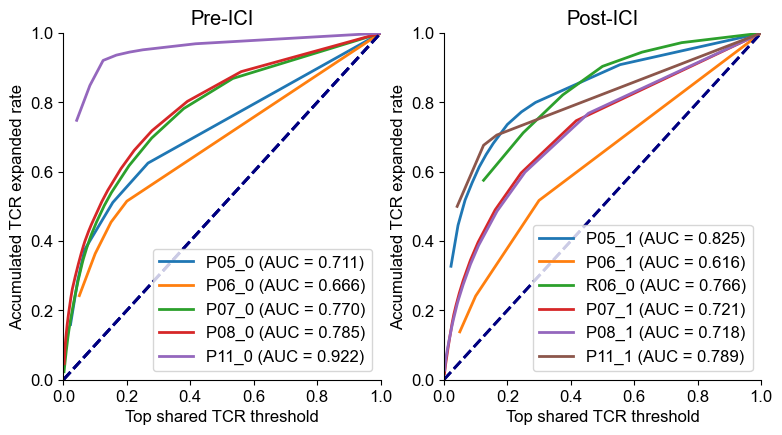

In [851]:
_, cc_pre = get_expand_clonotypes(mdata_CD8Tex[mdata_CD8Tex.obs['gex:treatment'].isin(['Pre'])], groupby='gex:batch', ntop=20)
_, cc_post = get_expand_clonotypes(mdata_CD8Tex[mdata_CD8Tex.obs['gex:treatment'].isin(['Post', 'Recu'])], groupby='gex:batch', ntop=20)
pres_clones = []
fig, ax = plt.subplots(1, 2, figsize=(9,4.5))
for i,p in enumerate(['5', '6', '7', '8', '11']): # ['5', '6', '7', '8', '11']
  cloneCounts_pre = cc_pre[f'NK{p}_0']#[cc_pre[f'NK{p}_0'] >= 1]
  cloneCounts_post = cc_post[f'NK{p}_1']#[cc_post[f'NK{p}_1'] >= 1]
  total_pre = sum(cc_pre[f'NK{p}_0'])
  total_post = sum(cc_post[f'NK{p}_1'])
  common_clone = list(set(cloneCounts_post.index).intersection(cloneCounts_pre.index))
  cloneCounts_pre = cloneCounts_pre[common_clone].sort_values(ascending=False)
  cloneCounts_post = cloneCounts_post[common_clone].sort_values(ascending=False)
  # AUC pre
  AUC_pre = pd.DataFrame(list(cloneCounts_pre.cumsum()), columns=['cumsum'])
  AUC_pre['P'] = np.array(list(cloneCounts_pre)) / sum(cloneCounts_pre)
  AUC_pre['TPR'] = AUC_pre['cumsum'] / sum(cloneCounts_pre)
  AUC_pre['FPR'] = np.array(range(1, len(AUC_pre)+1))/len(AUC_pre)

  AUC_post = pd.DataFrame(list(cloneCounts_post.cumsum()), columns=['cumsum'])
  AUC_post['P'] = np.array(list(cloneCounts_post)) / sum(cloneCounts_post)
  AUC_post['TPR'] = AUC_post['cumsum'] / sum(cloneCounts_post)
  AUC_post['FPR'] = np.array(range(1, len(AUC_post)+1))/len(AUC_post)

  auc_pre = auc(AUC_pre['FPR'],AUC_pre['TPR']) if len(AUC_pre) >=2 else 0
  auc_post = auc(AUC_post['FPR'],AUC_post['TPR']) if len(AUC_post) >=2 else 0
  print(f"P{p} Clonality post:{clonality(AUC_post['P'])}, pre:{clonality(AUC_pre['P'])}")
  print(f"P{p} Shannon post:{shannon_entropy(AUC_post['P'])}, pre:{shannon_entropy(AUC_pre['P'])}")
  x, y = int(i/2), i%2
  labpre = f'P0{p}_0 (AUC = %0.3f)' % auc_pre if int(p) < 10 else f'P{p}_0 (AUC = %0.3f)' % auc_pre
  labpost = f'P0{p}_1 (AUC = %0.3f)' % auc_post if int(p) < 10 else f'P{p}_1 (AUC = %0.3f)' % auc_post
  sns.lineplot(ax=ax[0], data=AUC_pre, x='FPR', y='TPR', label=labpre, lw=2)
  sns.lineplot(ax=ax[1], data=AUC_post, x='FPR', y='TPR', label=labpost, lw=2)
  
  if p == '6':
    cloneCounts_post = cc_post[f'RR{p}_0']#[cc_pre[f'NK{p}_0'] >= 1]
    total_post = sum(cc_post[f'RR{p}_0'])
    common_clone = list(set(cloneCounts_post.index).intersection(common_clone))
    print(f"Common_clone:{common_clone}")
    cloneCounts_post = cloneCounts_post[common_clone].sort_values(ascending=False)
    AUC_post = pd.DataFrame(list(cloneCounts_post.cumsum()), columns=['cumsum'])
    AUC_post['P'] = np.array(list(cloneCounts_post)) / sum(cloneCounts_post)
    AUC_post['TPR'] = AUC_post['cumsum'] / sum(cloneCounts_post)
    AUC_post['FPR'] = np.array(range(1, len(AUC_post)+1))/len(AUC_post)
    auc_post = auc(AUC_post['FPR'],AUC_post['TPR']) if len(AUC_post) >=2 else 0
    sns.lineplot(ax=ax[1], data=AUC_post, x='FPR', y='TPR', label=f'R0{p}_0 (AUC = %0.3f)' % auc_post, lw=2)
  else:
    pres_clones.extend(common_clone)

  ax[y].set_xlabel('Top shared TCR threshold')
  ax[y].set_ylabel('Accumulated TCR expanded rate')
  ax[y].legend(loc="lower right")
  ax[y].set_xlim([0.0, 1.0])
  ax[y].set_ylim([0.0, 1.0])
  sns.lineplot(ax=ax[y], x=[0, 1], y=[0, 1], lw=2, linestyle='--', color='navy')
ax[0].set_title('Pre-ICI')
ax[1].set_title('Post-ICI')
ax[0].spines['top'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[1].spines['right'].set_visible(False)
fig.savefig(f"{figPath}/Fig4d.pdf", bbox_inches='tight')

#### **Fig. 5f-g** Violin plots showing responder and nonresponder signatures across pre- and post-ICI samples from nonrecurrence patients (f) and across pre-ICI, post-ICI, and recurrence samples from a patient with recurrence (g).

In [853]:
# Subset the data to retain only cells belonging to persistent clonotypes.
# These specific clone IDs were identified as being shared across both 
# Pre-ICI and Post-ICI timepoints, representing the persistent TCR repertoire.
mdata_pres = mdata_T[mdata_T.obs['airr:clone_id'].isin(['28574', '28235', '28231', '28423', '28158', '28198', '28517', '28269'])]
responders = ['CXCL13', 'LYST', 'DUSP4', 'GZMK', 'RBPJ', 'HLA-DQA1', 'ZNF683',]
non_responders = ['FOS', 'GZMH',  'ANXA1', 'CTSC', 'XCL2']
sc.tl.score_genes(mdata_pres['gex'], gene_list=responders, score_name='responders')
sc.tl.score_genes(mdata_pres['gex'], gene_list=non_responders, score_name='non_responders')

/home/rzh/miniconda3/lib/python3.11/site-packages/scanpy/tools/_score_genes.py:165: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



In [854]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Extract relevant columns (responders score and batch ID) from the observation metadata
df = mdata_pres['gex'].obs[['responders','batch']]

# Group the responder scores by batch and aggregate them into lists for ANOVA input
groups = df.groupby('batch').agg(list)

# ---------------------------------------------------------
# One-way ANOVA Analysis
# ---------------------------------------------------------
# Perform One-way ANOVA to test if there are statistically significant 
# differences in responder scores between the three batches (NK6_0, NK6_1, RR6_0).
# Null Hypothesis (H0): All group means are equal.
# Alternative Hypothesis (H1): At least one group mean is different.
# ---------------------------------------------------------
f_statistic, p_value = stats.f_oneway(groups.loc['NK6_0', 'responders'], 
                                      groups.loc['NK6_1', 'responders'], 
                                      groups.loc['RR6_0', 'responders'])

# Output the ANOVA results
print("Responders ANOVA Results:\n")
print(f"F-statistic: {f_statistic}")
print(f"P-value: {p_value}")

# ---------------------------------------------------------
# Hypothesis Testing and Post-hoc Analysis
# ---------------------------------------------------------
# Evaluate the p-value against the significance level (alpha = 0.05)
alpha = 0.05
if p_value < alpha:
    # Reject the null hypothesis: Significant difference exists
    print("Reject the null hypothesis; at least one group mean is significantly different from the others.")
    
    # Perform Tukey's Honestly Significant Difference (HSD) test
    # This post-hoc test identifies exactly which pairs of batches differ significantly
    tukey = pairwise_tukeyhsd(endog=df['responders'], groups=df['batch'], alpha=alpha)
    print("\nTukey's HSD Pairwise Comparison Results:")
    print(tukey)
else:
    # Fail to reject the null hypothesis: No significant difference found
    print("Fail to reject the null hypothesis; there are no significant differences between group means.")

Responders ANOVA Results:

F-statistic: 4.8481296206096625
P-value: 0.009934981623515391
Reject the null hypothesis; at least one group mean is significantly different from the others.

Tukey's HSD Pairwise Comparison Results:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
 NK6_0  NK6_1  -0.0112 0.9479 -0.0969 0.0745  False
 NK6_0  RR6_0  -0.0697 0.0459 -0.1384 -0.001   True
 NK6_1  RR6_0  -0.0585 0.0649 -0.1198 0.0028  False
---------------------------------------------------


/tmp/ipykernel_3335451/2043497689.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [855]:
def Gexplot_adata(adata, gene, ax, group='batch'):
  """
  Plots gene expression violin plots and performs statistical analysis.
  
  This function visualizes the expression of a specified gene (either from .obs 
  or .var_names) across different groups. It automatically performs a One-way 
  ANOVA test to check for global differences and a Tukey's HSD post-hoc test 
  for pairwise comparisons. The plot is annotated with significance stars and 
  statistical values.
  
  Parameters:
  -----------
  adata : AnnData
      The input AnnData object.
  gene : str
      The gene name or metadata column to plot.
  ax : matplotlib.axes.Axes
      The matplotlib axis to plot on.
  group : str, optional
      The column in adata.obs to group by (default is 'batch').
      
  Returns:
  --------
  matplotlib.axes.Axes
      The modified axis object with the violin plot and annotations.
  """
  sns.set_style("ticks")
  
  # Check if the gene is in metadata (.obs) or expression matrix (.var_names)
  if gene in adata.obs.columns:
    data = adata.obs[[gene, group]]
  elif gene in adata.var_names:
    data = adata.obs[[group]]
    # Extract expression data from sparse matrix and flatten
    data[gene] = np.array(adata[:,gene].X.todense()).flatten()
  else:
    raise ValueError(f"{gene} not found in .obs or .var_names.")
    
  # Generate the violin plot
  sc.pl.violin(adata, keys=[gene], groupby=group, width=.6, ax=ax, show=False)
  
  # Prepare data for statistical testing
  groups = data.groupby(group).agg(list)
  
  # Perform One-way ANOVA
  f_statistic, pval = stats.f_oneway(groups.loc['NK6_0', gene], 
                                        groups.loc['NK6_1', gene], 
                                        groups.loc['RR6_0', gene])
  
  # Determine significance stars based on p-value
  if pval < 0.001:
    star = '***'
  elif pval < 0.01:
    star = '**'
  elif pval < 0.05:
    star = '*'
  else:
    star = 'ns'
    
  # Hypothesis testing and Post-hoc analysis
  alpha = 0.05
  if pval < alpha:
      # Reject the null hypothesis
      print("Reject the null hypothesis; at least one group mean is significantly different.")
      
      # Perform Tukey's HSD pairwise comparison
      tukey = pairwise_tukeyhsd(endog=data[gene], groups=data[group], alpha=alpha)
      print("\nTukey's HSD Pairwise Comparison Results:")
      print(tukey)
  else:
      # Fail to reject the null hypothesis
      print("Fail to reject the null hypothesis; no significant difference between group means.")
      
  # Adjust plot aesthetics and add annotations
  ax.set_ylim(min(data[gene])-0.05, max(data[gene]+0.3))
  ax.set_xticklabels(['NK6_0', 'NK6_1', 'RR6_0'])
  
  # Draw significance bracket and text
  sns.lineplot(x=[0, 2], y=max(data[gene])+0.3, color='black', linewidth=1.2, ax=ax)
  ax.text(1, max(data[gene])+0.3, f"ANOVA F={f_statistic:.3f},p={pval:.2e}\n{star}", fontsize=12, horizontalalignment='center')
  
  # Remove top and right spines
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  
  return ax

/tmp/ipykernel_3335451/1069155420.py:43: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Reject the null hypothesis; at least one group mean is significantly different.

Tukey's HSD Pairwise Comparison Results:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
 NK6_0  NK6_1  -0.0112 0.9479 -0.0969 0.0745  False
 NK6_0  RR6_0  -0.0697 0.0459 -0.1384 -0.001   True
 NK6_1  RR6_0  -0.0585 0.0649 -0.1198 0.0028  False
---------------------------------------------------


/tmp/ipykernel_3335451/1069155420.py:76: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_3335451/1069155420.py:43: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Reject the null hypothesis; at least one group mean is significantly different.

Tukey's HSD Pairwise Comparison Results:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
 NK6_0  NK6_1   0.0918   0.18 -0.0307 0.2143  False
 NK6_0  RR6_0   0.1905    0.0  0.0923 0.2887   True
 NK6_1  RR6_0   0.0987 0.0234   0.011 0.1863   True
---------------------------------------------------


/tmp/ipykernel_3335451/1069155420.py:76: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_3335451/4118478333.py:7: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_3335451/4118478333.py:8: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



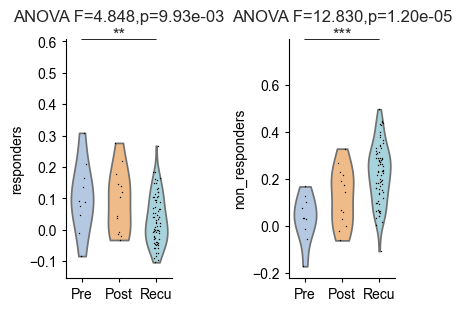

In [856]:
plt.style.use('default')
fig, ax = plt.subplots(1,2, figsize=(4.5,3), constrained_layout=True)
ax[0] = Gexplot_adata(mdata_pres['gex'], 'responders', ax=ax[0], group='batch')
ax[1] = Gexplot_adata(mdata_pres['gex'], 'non_responders', ax=ax[1], group='batch')
ax[0].set_xlabel('')
ax[1].set_xlabel('')
ax[0].set_xticklabels(['Pre', 'Post', 'Recu'])
ax[1].set_xticklabels(['Pre', 'Post', 'Recu'])
ax[0].tick_params(axis='both', which='both', length=3)
ax[1].tick_params(axis='both', which='both', length=3)
fig.savefig(f"{figPath}/Fig5f-g.pdf", bbox_inches='tight')

#### **Table 8.** Simulation analysis comparing TCR repertoire metrics.

In [871]:
# Comparison between Shannon entropy and our AUC-curve based method
import numpy as np
from sklearn.metrics import auc

def calculate_auc_clonal_expansion(frequencies):
    """
    Calculates the Area Under the Curve (AUC) for clonal expansion.
    This metric quantifies the degree of oligoclonality by measuring the 
    cumulative frequency of top-ranked clones.
    """
    # Normalize frequencies to sum to 1
    frequencies = frequencies / np.sum(frequencies)
    # Sort frequencies in descending order
    sorted_freq = np.sort(frequencies)[::-1]
    # X-axis: Clone rank proportion (0 to 1)
    clone_rank = np.arange(1, len(sorted_freq)+1) / len(sorted_freq)
    # Y-axis: Cumulative cell proportion
    cumulative_cells = np.cumsum(sorted_freq)
    return auc(clone_rank, cumulative_cells)

# ==============================
# Construct 3 sets of simulated TCR repertoire data
# (First 3 high abundance, rest with fluctuations)
# ==============================
np.random.seed(42)  # Fix seed for reproducibility
n_total = 1000  # Total number of clones (consistent with real sequencing data)

# Set 1: Baseline group (No expansion, uniform distribution + small fluctuations)
freq1 = np.random.uniform(low=0.00095, high=0.00105, size=n_total)
freq1 = freq1 / np.sum(freq1)

# Set 2: Moderate expansion group (Top 3 account for 30%, rest have fluctuations)
top2 = np.array([0.14, 0.10, 0.06])  # Sum of top 3 is 0.3
rare_base2 = 0.7 / 997
rare2 = np.random.uniform(low=rare_base2*0.8, high=rare_base2*1.2, size=997)
freq2 = np.concatenate([top2, rare2])
freq2 = freq2 / np.sum(freq2)

# Set 3: Strong expansion group (Top 3 account for 50%, rest have fluctuations)
top3 = np.array([0.22, 0.18, 0.10])  # Sum of top 3 is 0.5
rare_base3 = 0.5 / 997
rare3 = np.random.uniform(low=rare_base3*0.8, high=rare_base3*1.2, size=997)
freq3 = np.concatenate([top3, rare3])
freq3 = freq3 / np.sum(freq3)

# Calculate and print results
for name, f in [("Set 1 (Baseline, No Expansion)", freq1), 
                ("Set 2 (Moderate Oligoclonal Expansion)", freq2), 
                ("Set 3 (Strong Oligoclonal Expansion)", freq3)]:
    H = shannon_entropy(f)
    Clon = clonality(f)
    AUC = calculate_auc_clonal_expansion(f)
    print(f"=== {name} ===")
    print(f"Shannon Entropy: {H:.3f} (Change Rate: {(H - shannon_entropy(freq1))/shannon_entropy(freq1)*100:.1f}%)")
    print(f"Clonality:       {Clon:.3f}")
    print(f"AUC (expansion): {AUC:.3f} (Change Rate: {(AUC - calculate_auc_clonal_expansion(freq1))/calculate_auc_clonal_expansion(freq1)*100:.1f}%)\n")

=== Set 1 (Baseline, No Expansion) ===
Shannon Entropy: 6.907 (Change Rate: 0.0%)
Clonality:       0.000
AUC (expansion): 0.508 (Change Rate: 0.0%)

=== Set 2 (Moderate Oligoclonal Expansion) ===
Shannon Entropy: 5.756 (Change Rate: -16.7%)
Clonality:       0.167
AUC (expansion): 0.672 (Change Rate: 32.1%)

=== Set 3 (Strong Oligoclonal Expansion) ===
Shannon Entropy: 4.669 (Change Rate: -32.4%)
Clonality:       0.324
AUC (expansion): 0.765 (Change Rate: 50.5%)

